# 07. Publication Figure 3: Disentangling Position from Model Weight

## Research Method
To isolate true algorithmic quality from layout bias, we stratify keywords into **Weight Quintiles** and evaluate selection probability across positional deciles.


/tmp/ipykernel_141/3885290292.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ortho_df = df.groupby(['weight_quintile', 'displayed_position'])['selected'].mean().reset_index()


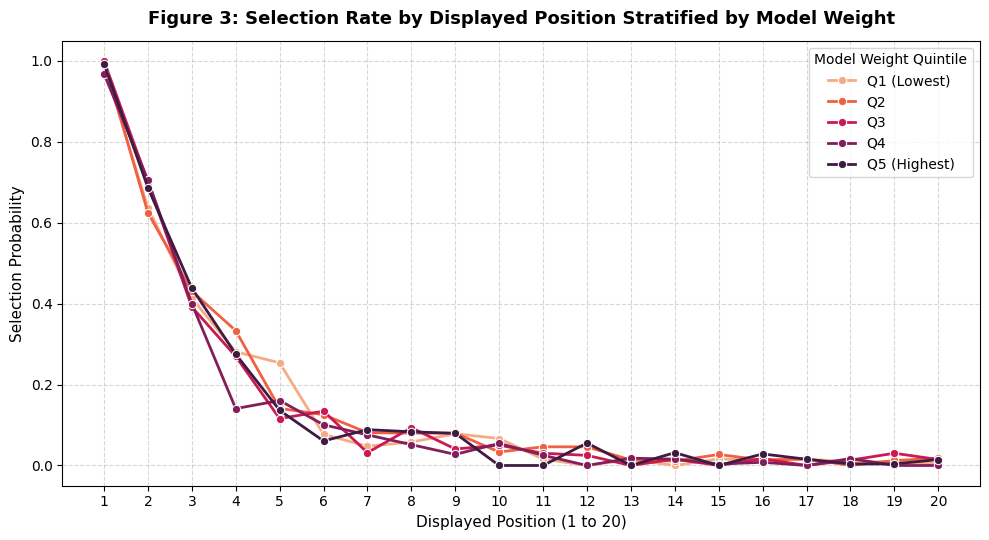

Figure 3 rendered and exported successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/mnt/data/h2_testing_dataset.csv')

# Partition model weight into quintiles
df['weight_quintile'] = pd.qcut(df['model_weight'], q=5, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])

ortho_df = df.groupby(['weight_quintile', 'displayed_position'])['selected'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5.5))
palette = sns.color_palette("rocket_r", n_colors=5)

sns.lineplot(data=ortho_df, x='displayed_position', y='selected', hue='weight_quintile', 
             palette=palette, marker='o', lw=2, ax=ax)

ax.set_title("Figure 3: Selection Rate by Displayed Position Stratified by Model Weight", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Displayed Position (1 to 20)", fontsize=11)
ax.set_ylabel("Selection Probability", fontsize=11)
ax.set_xticks(range(1, 21))
ax.legend(title="Model Weight Quintile", frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/mnt/data/github_replication_suite/notebooks/figure3_weight_orthogonality.png', dpi=300)
plt.show()
print("Figure 3 rendered and exported successfully.")
